# Demo

Import libraries

In [10]:
import torch
from torchinfo import summary
import yaml
from training import Trainer
import os
from utils import get_data, create_model_name
from accelerate import Accelerator # for multigpu
from dotenv import load_dotenv
load_dotenv()  # take environment variables from .env file

True

Configurations

In [11]:
# load configurations from config.yaml
config_file = os.path.join(os.getcwd(), "config.yaml")
with open(config_file) as file:
    config = yaml.safe_load(file)
# get dataset path from .env file
if config["data"]["dataset_path"] is None:
    config["data"]["dataset_path"] = os.getenv("DATASET_PATH") 

# accelerator for multigpu
accelerator = Accelerator()

Load dataset

In [12]:
# dataset
train_loader, val_loader, test_loader = get_data(config, verbose=True)
train_loader, val_loader, test_loader = accelerator.prepare(train_loader, val_loader, test_loader)

Resizing images from [720, 1280] to [45, 80]
Total dataset size: 10300
Len train dataset: 32, Len val dataset: 32


## Encoder

## Decoder

In [4]:
print(f"Current dir \"{os.path.abspath(os.curdir)}\"")
# plot trained models
trained_decoders = os.listdir("fourier_mlp_decoder/")
print("Available trained decoders:", *trained_decoders, sep="\n- ")


Current dir "d:\Jack\KTH\Research project in Robotics\cloudgripper-visual-autoencoder\visual_autoencoder"
Available trained decoders:
- debug_datapath_train32_val32_batch32_xyzrg
- debug_freq_train32_val32_batch32_xyzrg
- debug_reconstruction_train32_val32_batch32_xyzrg
- debug_save_load_train32_val32_batch32_xyzrg


Load trained model

In [5]:
MODEL_TO_LOAD = "debug_freq_train32_val32_batch32_xyzrg"

In [6]:
from architecture import FourierMlpDecoder

# load trained model
decoder = FourierMlpDecoder(
    model_name=MODEL_TO_LOAD,
    accelerator=accelerator,
    config=config, # TODO: local config
)
decoder.load_model()
# from accelerate import load_checkpoint_in_model
# load_checkpoint_in_model(decoder,
#                          os.path.join("fourier_mlp_decoder", "debug_save_load_train32_val32_batch32_xyzrg"), 
# )#device_map={"":decoder.device})
decoder = accelerator.prepare(decoder)
summary(decoder, input_size=(1, len(config["model"]["dimensions_to_learn"])))
decoder.eval()
decoder_trainer = Trainer(decoder, config)

Train batch-loss MSE: 0.001116913161240518
Train batch-loss RMSE: 0.033420250765673766
Output shape: (32, 3, 45, 80)
Robot configuration x=0.780, y=0.500, z=0.167, r=0.000, g=1.000


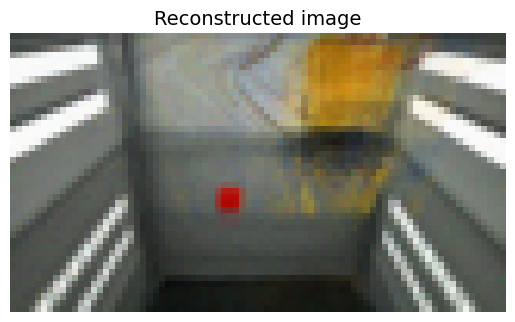

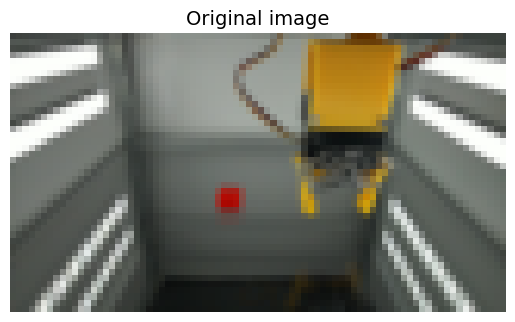

In [23]:
batch = next(iter(train_loader))
images, labels = batch

# inference on train set
output, loss = decoder_trainer._inference_step(batch)
loss = loss.item()
output = output.detach().numpy()

print("Train batch-loss MSE:", loss)
print("Train batch-loss RMSE:", loss**0.5)
print("Output shape:", output.shape)
# plot original and reconstructed images
from gripper_data import plot_image
num_sample = 8
print(f"Robot configuration x={labels[num_sample,0]:.3f}, y={labels[num_sample,1]:.3f}, z={labels[num_sample,2]:.3f}, r={labels[num_sample,3]:.3f}, g={labels[num_sample,4]:.3f}")
plot_image(output[num_sample], title="Reconstructed image")
plot_image(images[num_sample], title="Original image")

 inference on test set

Inference on test set:
Test loss MSE: 0.0029672838281840086
Test loss RMSE: 0.05447278061733225
Output shape: (32, 3, 45, 80)
Robot configuration x=0.480, y=0.500, z=0.739, r=0.000, g=1.000


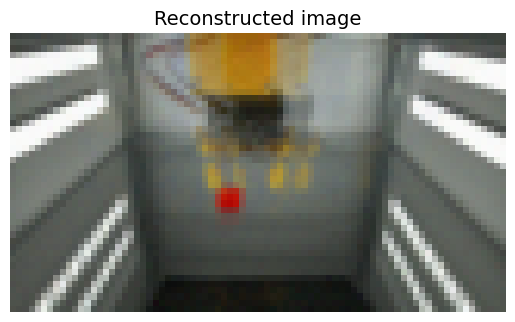

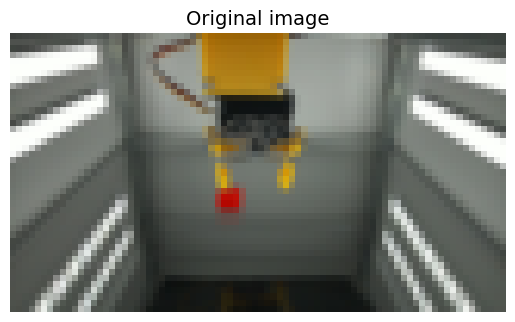

In [21]:
batch = next(iter(test_loader))
images, labels = batch

# inference on train set
output, loss = decoder_trainer._inference_step(batch)
loss = loss.item()
output = output.detach().numpy()

print("Inference on test set:")
print("Test loss MSE:", loss)
print("Test loss RMSE:", loss**0.5)
print("Output shape:", output.shape)
# plot original and reconstructed images
from gripper_data import plot_image
num_sample = 1
print(f"Robot configuration x={labels[num_sample,0]:.3f}, y={labels[num_sample,1]:.3f}, z={labels[num_sample,2]:.3f}, r={labels[num_sample,3]:.3f}, g={labels[num_sample,4]:.3f}")
plot_image(output[num_sample], title="Reconstructed image")
plot_image(images[num_sample], title="Original image")
